In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
# import MyHaloPS as ps
# import importlib
# importlib.reload(ps)
import pickle
import scipy
#import Corrfunc

from scipy.optimize import curve_fit
# from Corrfunc.theory import xi

In [29]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [30]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [34]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [35]:
def cf_lin_excl(r, bias=1, R=0.15):
    d = 2*R
    mask = r < d
    bias_factor=bias**2
    cf = bias_factor*cf_lin(r)
    cf[mask] = -1
    return cf

In [39]:
def cf_nl_excl(r, bias=1, R=0.15):
    d = 2*R
    mask = r < d
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    cf[mask] = -1
    return cf

In [40]:
def cf_lin_w_bias(r, bias=1,R=None):
    bias_factor=bias**2
    cf = bias_factor*cf_lin(r)
    return cf

def cf_nl_w_bias(r, bias=1, R=None):
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    return cf

def lognormal_cf(xi_c, sigma, R,bias=1, rmax=3, dr=0.1):
    #dr = 0.00003
    Nr = int( rmax / dr )
  
    r_list = np.array([ dr * (i+1) for i in range(Nr) ])
    
    d = 2*R
    x = np.log10(r_list / d) / (np.sqrt(2) * sigma)
    fr = 1 - 0.5 * (1.0 + scipy.special.erf(x))
    if sigma == 0:
        xi_d = xi_c(r_list,bias=bias)
    else:
        xi_d = (1 - fr) * (xi_c(r_list, bias=bias) + 1) - 1

    return r_list, xi_d

def pk_from_cf(logks, R=0.2):
    rmax = 205
    dr=0.001
    r_list = np.arange(1e-4,rmax,dr)
    #cf = cf_lin_excl(r_list, R=R)
    cf = cf_nl_excl(r_list, R=R)
    #r_list, cf = lognormal_cf(cf_nl_w_bias, sigma=0.175, R=0.38, bias=2, rmax=rmax, dr=dr)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [41]:
logks = np.arange(-1.5,1.6,0.01)
ks = 10**logks
pk1 = pk_from_cf(logks, R=0.5)
pk2 = pk_from_cf(logks, R=0.2)
kcoef = ks**3/(2*np.pi**2)

pklin = Plin(10**logks)

pknl = Pnl(10**logks)
pk2_nl = pk_from_cf(logks, R=0.2)

Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h\\ Mpc^{-1}]})$')

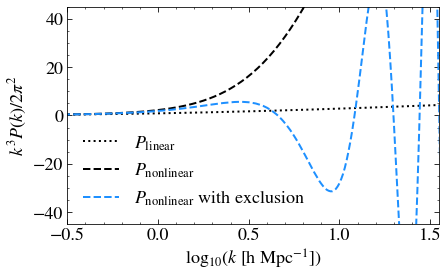

In [46]:
plt.plot(logks, kcoef*pklin, linestyle="dotted", c='k', label="$P_{\mathrm{linear}}$")
plt.plot(logks, kcoef*pknl, linestyle="dashed", c='k', label="$P_{\mathrm{nonlinear}}$")
plt.plot(logks, kcoef*pk2_nl, c="DodgerBlue", linestyle="dashed", label="$P_{\mathrm{nonlinear}}$ with exclusion")
#plt.plot(logks, kcoef*pk2, c="crimson", label="$D=0.4$")
plt.xlim(-0.5,1.55)
plt.legend()
plt.ylim(-45,45)

plt.ylabel("$k^3 P(k) / 2 \pi^2$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")

#plt.savefig("../figures/halo_exclusion_cartoon.pdf", format="pdf", bbox_inches="tight")